# Opdracht: Rule-Based Tic-tac-toe Policy Opdracht

## Doel
Ontwikkel een rule-based systeem dat het spel boter-kaas-en-eieren (tic-tac-toe) kan spelen binnen de PettingZoo omgeving door de huidige speelsituatie te analyseren en de beste zet te bepalen.

## Context
Je krijgt een basis spelomgeving aangeleverd die het spel simuleert via PettingZoo. De observatie komt in de volgende vorm:
- `observation["board"]`: Een 1D array van lengte 9 die het bord representeert
- `observation["action_mask"]`: Een boolean array die aangeeft welke acties geldig zijn
- De waardes op het bord zijn:
  - 0: leeg veld
  - 1: speler 1 ('X')
  - 2: speler 2 ('O')

## Opdracht
1. **Analyseer het Spelbord**
   - Schrijf functies die het bord (observation["board"]) analyseren op:
     - Horizontale rijen
     - Verticale kolommen
     - Diagonalen

  deze kunnen dan gebruikt worden om te identificeren of :
     - Er al gewonnen is
     - Je kunt winnen in één zet
     - De tegenstander kan winnen in één zet
     - Je een "vork" kunt maken (twee winnende zetten tegelijk)

2. **Definieer Regels**
   Implementeer de volgende prioriteitsregels:
   1. Win als je kunt
   2. Blokkeer een dreigende winst van de tegenstander
   3. Creëer een vork als mogelijk
   4. Blokkeer een mogelijke vork van de tegenstander
   5. Neem het centrum als het vrij is
   6. Neem een hoek als het centrum bezet is
   7. Neem een zijkant als niets anders beschikbaar is

3. **Implementeer het Systeem**
   Zorg dat je systeem:
   - Alleen geldige zetten kiest (check observation["action_mask"])
   - De juiste speler identifier gebruikt (1 voor player_1, 2 voor player_2)
   - Een actie returnt als integer tussen 0-8

In [ ]:
pip install pettingzoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 51.8 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
from pettingzoo.classic import tictactoe_v3

# Initialiseer de omgeving
env = tictactoe_v3.env(render_mode="rgb_array")
env.reset(seed=42)

def convert_observation(obs):
    """
    Convert PettingZoo tic-tac-toe observation (3x3x2) to a 1D array (length 9)
    where: 0 = empty, 1 = player 1 (X), 2 = player 2 (O)

    Args:
        obs: 3x3x2 numpy array where:
            - first two dimensions are board position
            - third dimension: [1,0] = X, [0,1] = O, [0,0] = empty

    Returns:
        1D numpy array of length 9 with values 0,1,2
    """
    board = np.zeros(9, dtype=int)

    for i in range(3):
        for j in range(3):
            if obs[i,j,0] == 1:  # X
                board[i*3 + j] = 1
            elif obs[i,j,1] == 1:  # O
                board[i*3 + j] = 2

    return board

def get_human_action(observation):
    """Vraag de menselijke speler om een zet"""
    mask = observation["action_mask"]
    board = observation["board"]

    # Maak een visualisatie van beschikbare zetten
    print("\nBeschikbare zetten (nummer = beschikbare positie):")
    visual_board = [" " for _ in range(9)]
    for i in range(9):
        if mask[i]:
            visual_board[i] = str(i)
        else:
            if board[i] == 1:
                visual_board[i] = "X"
            elif board[i] == 2:
                visual_board[i] = "O"
            else:
                visual_board[i] = "·"

    # Print het bord met beschikbare zetten
    print(f"{visual_board[0]} | {visual_board[3]} | {visual_board[6]}")
    print("---------")
    print(f"{visual_board[1]} | {visual_board[4]} | {visual_board[7]}")
    print("---------")
    print(f"{visual_board[2]} | {visual_board[5]} | {visual_board[8]}")

    while True:
        try:
            print("\nKies een zet door het nummer van de gewenste positie in te voeren:", end=" ")
            move = int(input())
            if mask[move]:
                return move
            else:
                print("Ongeldige zet, kies een van de getallen op het bord.")
        except ValueError:
            print("Voer een geldig nummer in zoals getoond op het bord.")

def rule_based_action(observation, agent):
    """
    Args:
        observation: Dict met 'board' en 'action_mask'
        agent: String met de huidige speler ('player_1' of 'player_2')
    Returns:
        action: Integer tussen 0-8 voor de gekozen zet
    """
    mask = observation["action_mask"]
    random = env.action_space(agent).sample(mask)
    return random



The code below runs the game. Where the rule based action of the opponent currently is a random strategy.


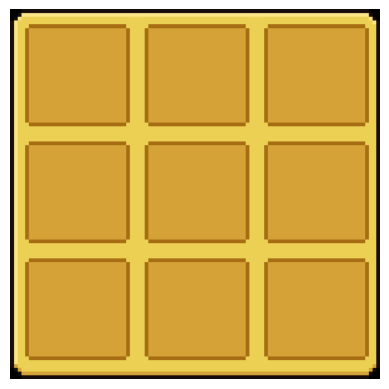


Beschikbare zetten (nummer = beschikbare positie):
0 | 3 | 6
---------
1 | 4 | 7
---------
2 | 5 | 8

Kies een zet door het nummer van de gewenste positie in te voeren: 4


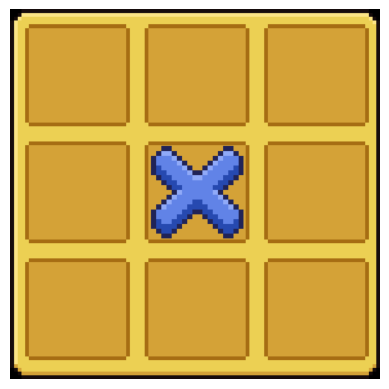

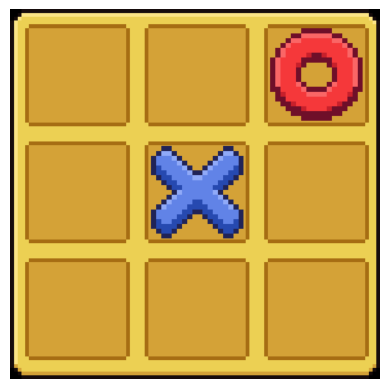


Beschikbare zetten (nummer = beschikbare positie):
0 | 3 | O
---------
1 | X | 7
---------
2 | 5 | 8

Kies een zet door het nummer van de gewenste positie in te voeren: 1


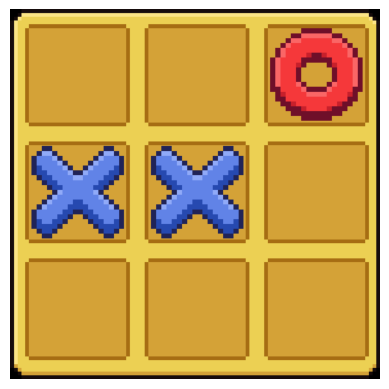

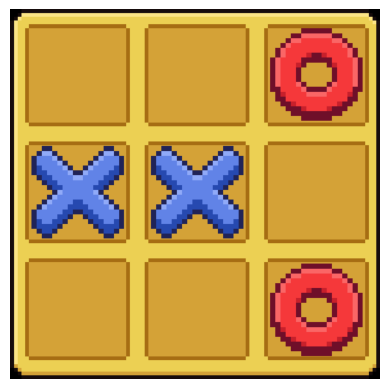


Beschikbare zetten (nummer = beschikbare positie):
0 | 3 | O
---------
X | X | 7
---------
2 | 5 | O

Kies een zet door het nummer van de gewenste positie in te voeren: 7


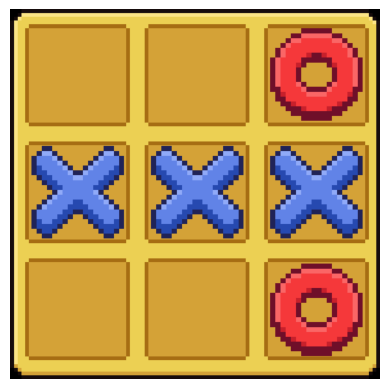

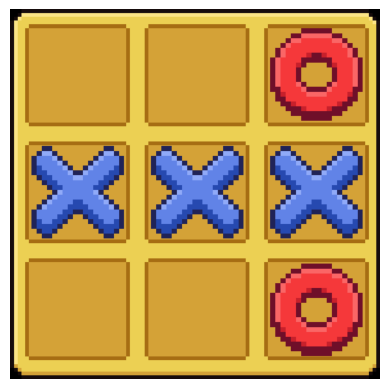


Gefeliciteerd, je hebt gewonnen!


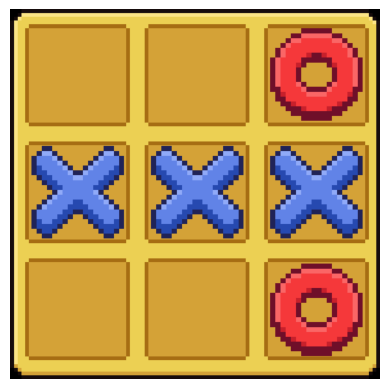

In [ ]:
env = tictactoe_v3.env(render_mode="rgb_array")
env.reset(seed=42)

rgb_image = env.render()
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        if reward == 1:
            print("\nGefeliciteerd, je hebt gewonnen!" if agent == "player_1" else "\nHelaas, de computer heeft gewonnen!")
        elif reward == 0:
            print("\nGelijkspel!")
        action = None
    else:
        board = convert_observation(raw_observation["observation"])
        observation = {
            "board": board,
            "action_mask": raw_observation["action_mask"]
        }

        # Speler 1 (mens) of Speler 2 (computer)
        if agent == "player_1":
            action = get_human_action(observation)
        else:
            action = rule_based_action(observation, agent)

    env.step(action)
    rgb_image = env.render()
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()

env.close()

Now redefine the rule_based_action function in order to apply the rules that are mentioned in the assigment.

In [ ]:
def rule_based_action(observation, agent):
    """
    Implementeer hier je rule-based systeem
    Args:
        observation: Dict met 'board' en 'action_mask'
        agent: String met de huidige speler ('player_1' of 'player_2')
    Returns:
        action: Integer tussen 0-8 voor de gekozen zet
    """
    # TODO: Implementeer je rule based system hier!
    mask = observation["action_mask"]
    random = env.action_space(agent).sample(mask)
    return random

# Opdracht 3 (optioneel) : Rulebased Systems - Prijsstrategie voor Luchtvaartmaatschappijen met Forward Chaining  

---  

### **Doel**:  
Je gaat een rulebased systeem ontwerpen dat de ticketprijs bepaalt voor vluchten die vertrekken vanaf Amsterdam Schiphol Airport (AMS) naar diverse bestemmingen. Door middel van forward chaining zal je systeem tussentijdse kenmerken afleiden op basis van observeerbare feiten om uiteindelijk de ticketprijs te berekenen.  

---  

### **Probleemstelling**:  
Luchtvaartmaatschappijen berekenen dynamisch ticketprijzen op basis van meerdere observeerbare factoren, zoals **tijd tot vertrek**, **beschikbaarheid van stoelen** en **klantcategorie**. Deze factoren leiden tot tussentijdse feiten, die vervolgens worden gebruikt om de uiteindelijke ticketprijs te bepalen.  

Je taak is om een rulebased systeem te bouwen dat de **ticketprijs** voor verschillende vluchten berekent op basis van vooraf gedefinieerde prijzen voor drie prijsklassen: **Goedkoop**, **Regulier** en **Duur**.  

#### **Vluchten en Prijzen**:  
De basisprijzen voor tickets naar de vijf bestemmingen zijn als volgt:  

| **Bestemming** | **Afstand (km)**        | **Goedkoop (€)** | **Regulier (€)** | **Duur (€)** |  
|----------------|--------------------------|------------------|------------------|--------------|  
| Londen         | 360                      | €50              | €100             | €200         |  
| Parijs         | 430                      | €60              | €120             | €240         |  
| Berlijn        | 650                      | €80              | €160             | €320         |  
| Rome           | 1.290                    | €120             | €240             | €480         |  
| Madrid         | 1.450                    | €130             | €260             | €520         |  

---  

### **Observeerbare Kenmerken**:  
De volgende observeerbare gegevens zijn beschikbaar voor je rulebased systeem:  
1. **Tijd tot vertrek (uren)**: Continue waarde (bijv. 48 uur, 24 uur).  
2. **Beschikbaarheid van stoelen**: Continu percentage (bijv. 80%, 50%).  
3. **Moment van de dag**: Stringwaarde (bijv. "ochtend", "middag", "avond").  
4. **Niveau van vraag**: Booleaanse waarde (`hoog` of `laag`).  
5. **Bestemming van de vlucht**: String (bijv. "Londen", "Parijs").  
6. **Klantcategorie**: String (`zakelijk` of `vrijetijd`).  

---  

### **Opdracht**:  
Je taak is om:  

1. Een simpele inference engine te maken.

2. Een set **regels** te ontwerpen die observeerbare kenmerken gebruiken om **tussentijdse feiten** af te leiden. Bijvoorbeeld:  
   - "Hoge urgentie" kan worden afgeleid uit "tijd tot vertrek < 24 uur" EN "klantcategorie == zakelijk".  

3. De tussentijdse feiten te combineren om de **prijsklasse** te bepalen (Goedkoop, Regulier, Duur).  

4. De prijsklasse en de vluchtbestemming te gebruiken om de **uiteindelijke ticketprijs** te berekenen.  

---  

### **Deliverables**:  
1. Een Python-script dat de logica implementeert.  
2. Een demonstratie van de uitvoer van je systeem met ten minste **drie scenario’s**, zoals hieronder beschreven.  

---  

### **Scenario’s**:  

#### **Scenario 1**:  
- **Tijd tot vertrek**: 20 uur  
- **Beschikbaarheid van stoelen**: 60%  
- **Moment van de dag**: Avond  
- **Niveau van vraag**: Hoog  
- **Bestemming van de vlucht**: Parijs  
- **Klantcategorie**: Zakelijk  

#### **Scenario 2**:  
- **Tijd tot vertrek**: 72 uur  
- **Beschikbaarheid van stoelen**: 30%  
- **Moment van de dag**: Ochtend  
- **Niveau van vraag**: Laag  
- **Bestemming van de vlucht**: Londen  
- **Klantcategorie**: Vrijetijd  

#### **Scenario 3**:  
- **Tijd tot vertrek**: 6 uur  
- **Beschikbaarheid van stoelen**: 20%  
- **Moment van de dag**: Avond  
- **Niveau van vraag**: Hoog  
- **Bestemming van de vlucht**: Rome  
- **Klantcategorie**: Zakelijk  

In [ ]:
# Rulebased inference-engine skeleton that can be used

class RuleEngine:
    def __init__(self):
        self.rules = []
        self.facts = {}

    def add_rule(self, conditions, action):
        """Voegt een regel toe met condities en een actie."""
        # TODO Implement


    def assert_fact(self, fact):
        """Voegt een feit toe en voert de relevante regels uit."""
        # TODO Implement

    def evaluate_rules(self):
        """Evalueert regels en voert acties uit als de condities waar zijn."""
        # TODO Implement

# TODO Implement the pricing strategy